In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
%matplotlib inline


In [6]:
irish = pd.read_csv("E:\Learning\Krish\Data cleaning\Iris.csv")

<>:1: SyntaxWarning: invalid escape sequence '\L'
<>:1: SyntaxWarning: invalid escape sequence '\L'
C:\Users\Kuldip Thakar\AppData\Local\Temp\ipykernel_11028\629446512.py:1: SyntaxWarning: invalid escape sequence '\L'
  irish = pd.read_csv("E:\Learning\Krish\Data cleaning\Iris.csv")


In [7]:
irish.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [49]:
irish= irish.drop(columns='Id')

In [50]:
print(irish.columns)

Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')


In [51]:
irish["Species"].value_counts()

#balanced dataset


Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

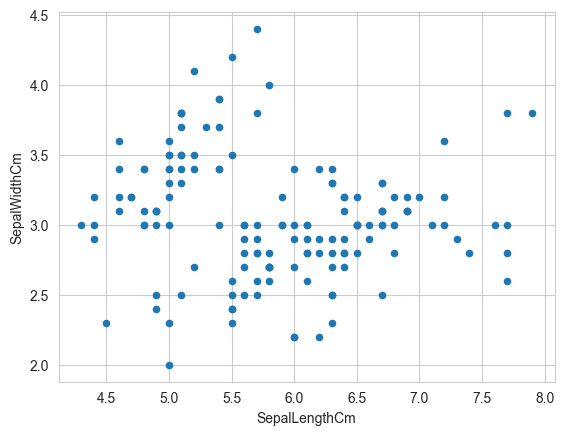

In [52]:
#2d Scatter plot
irish.plot(kind='scatter',x='SepalLengthCm',y= 'SepalWidthCm')
plt.show()

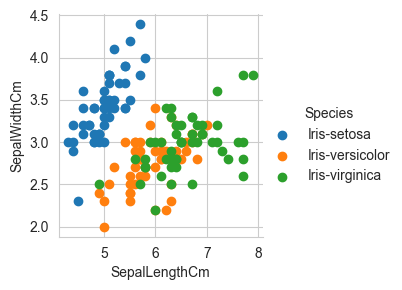

In [53]:
sns.set_style('whitegrid') # there are others too whitegrid, darkgrid, dark ,ticks
sns.FacetGrid(irish,hue="Species").map(plt.scatter,'SepalLengthCm','SepalWidthCm').add_legend() #This creates a FacetGrid, which is useful for visualizing multi-class data., The hue="Species" argument colors the points based on the Species column.
#This maps a scatter plot (plt.scatter) onto the grid.
plt.show()

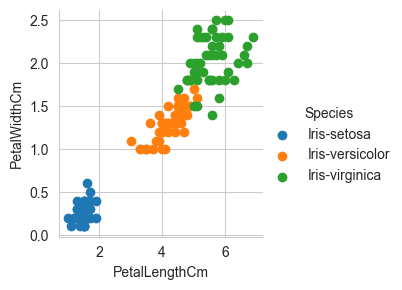

In [54]:
sns.set_style('whitegrid') # there are others too whitegrid, darkgrid, dark ,ticks
sns.FacetGrid(irish,hue="Species").map(plt.scatter,'PetalLengthCm','PetalWidthCm').add_legend() #This creates a FacetGrid, which is useful for visualizing multi-class data., The hue="Species" argument colors the points based on the Species column.
#This maps a scatter plot (plt.scatter) onto the grid.
plt.show()

c:\Users\Kuldip Thakar\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


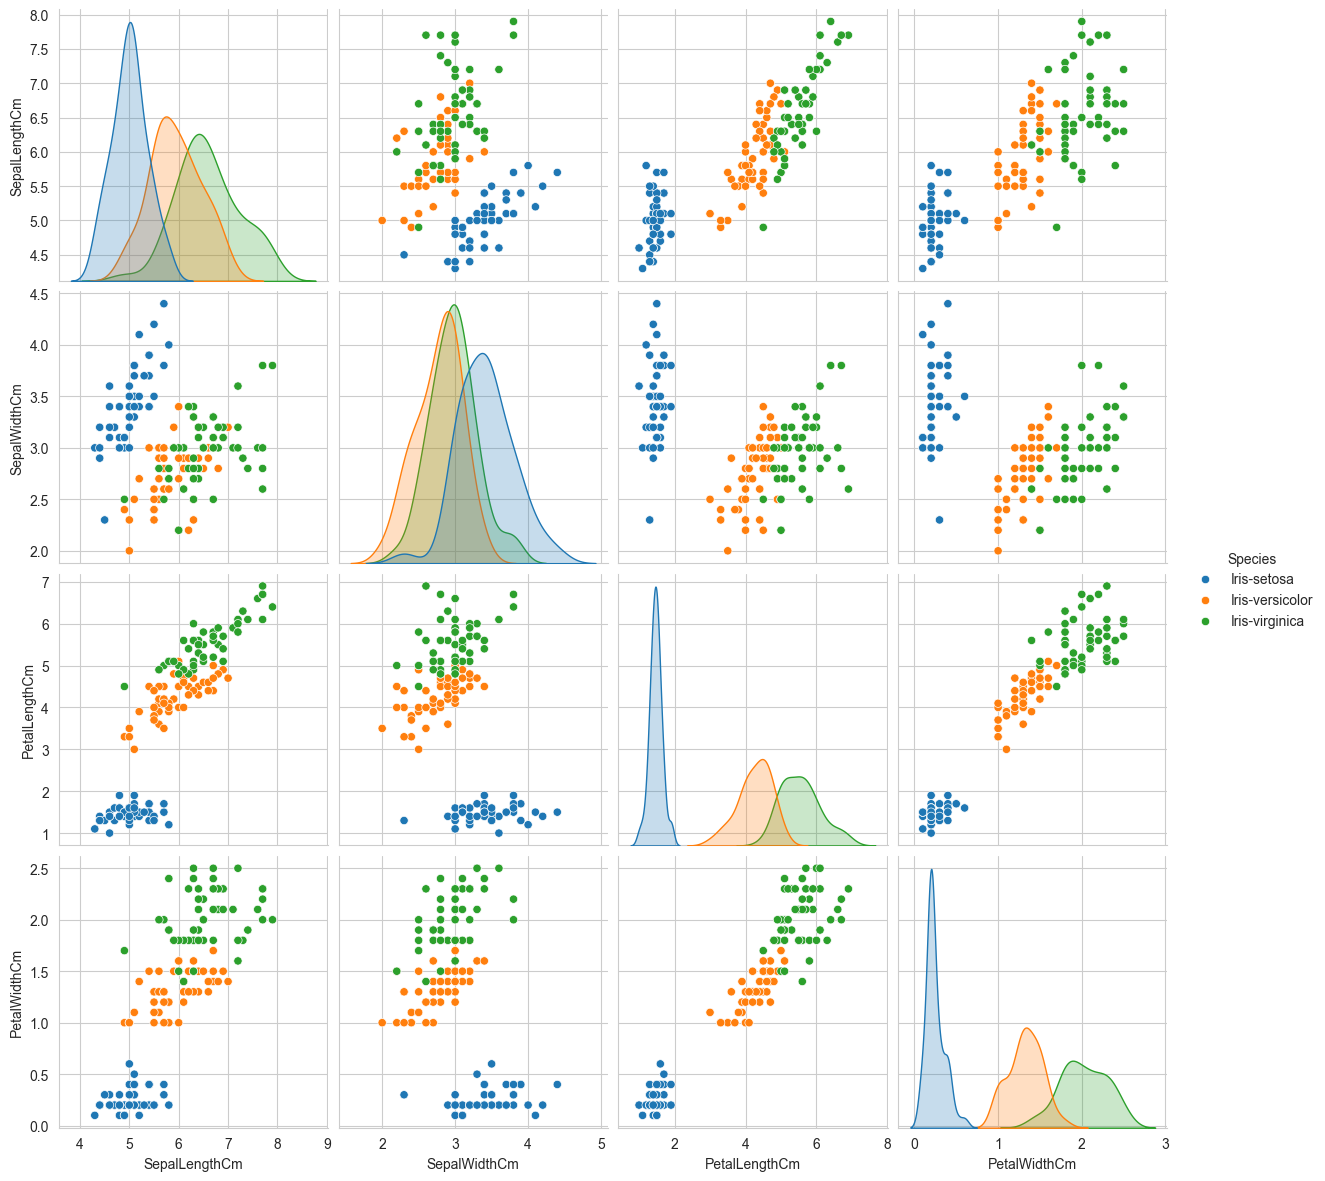

In [55]:
plt.close()
sns.set_style('whitegrid')
sns.pairplot(irish,hue="Species",size=3)

1. Petal_length and Petal_width are the most useful features to identify the various flower types
2. While Setosa can be easily identified(linerly seperable), Vihinica and versicolor have some overlap(almost linerly seprarabl)
3. We can find lines and if-else condition to build simple model to classify the flower type

#Limitation of pairplot
there were 4 feature 4c2 we had 
Pairplots are easy to understand when the dimentionality of the data is less ex<= 6 pairplot will not help

in that case we have to go with PCA, t-sne 
dimentionality reduction techiques


In [69]:
irish["Species"] = irish["Species"].str.replace("Iris", "", regex=True)


In [70]:
irish.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


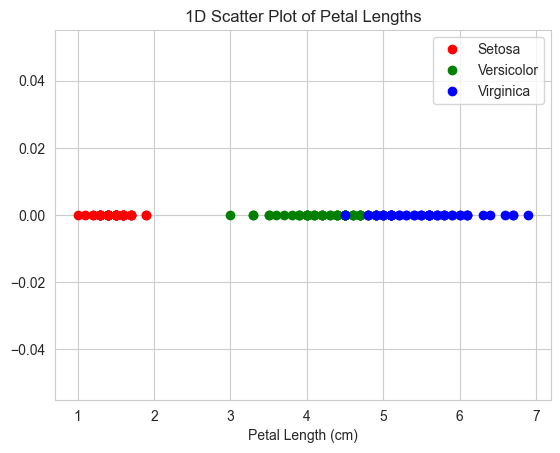

In [71]:
#Histogram PDF and CDF 

#WHAT ABOUT 1-D SCATTER PLOT JUST ONE FEATURE?
iris_setosa = irish.loc[irish["Species"] == "setosa"]
iris_versicolor = irish.loc[irish["Species"] == "versicolor"]
iris_virginica = irish.loc[irish["Species"] == "virginica"]

# Plotting each species separately
plt.plot(iris_setosa["PetalLengthCm"], np.zeros_like(iris_setosa["PetalLengthCm"]), 'ro', label="Setosa")
plt.plot(iris_versicolor["PetalLengthCm"], np.zeros_like(iris_versicolor["PetalLengthCm"]), 'go', label="Versicolor")
plt.plot(iris_virginica["PetalLengthCm"], np.zeros_like(iris_virginica["PetalLengthCm"]), 'bo', label="Virginica")

plt.xlabel("Petal Length (cm)")
plt.title("1D Scatter Plot of Petal Lengths")
plt.legend()
plt.show()


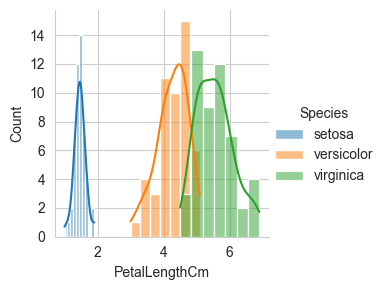

In [ ]:
#thereare place where some points are there whihc ever are overlapping also
#1D scatter plot like this is very hard to read
#HIstogram 

sns.FacetGrid(irish, hue="Species").map(sns.histplot,"PetalLengthCm",kde ="True").add_legend()
plt.show()

#as it is seen the versicolor and virginica is overlapping

#univariate analysis Means one variable analysis

suppose i have Saple length, saple width , petal length, petal width

the further this distribution are the better so putting up with every available data



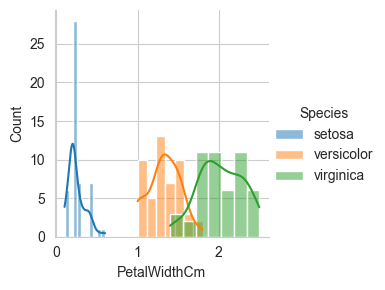

In [84]:
sns.FacetGrid(irish, hue="Species").map(sns.histplot,"PetalWidthCm",kde ="True").add_legend()
plt.show()

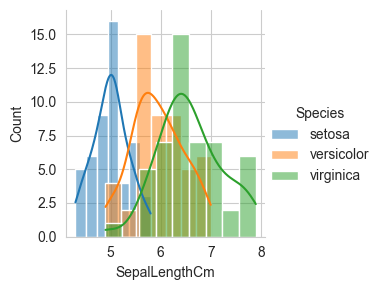

In [ ]:
sns.FacetGrid(irish, hue="Species").map(sns.histplot,"SepalLengthCm",kde ="True").add_legend()
plt.show()
#it is not reccomanded , this distribution has so much overlap 
#petal length was better or petal width

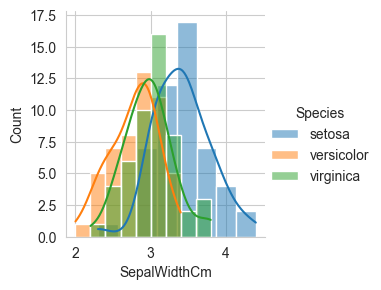

In [89]:
sns.FacetGrid(irish, hue="Species").map(sns.histplot,"SepalWidthCm",kde ="True").add_legend()
plt.show()

### Mean Variaance and Std-Dev

In [ ]:
print("Mean")
print(np.mean(iris_setosa["PetalLengthCm"]))
#Mean with outlier
print(np.mean(np.append(iris_setosa["PetalLengthCm"],50)))


print(np.mean(iris_virginica["PetalLengthCm"]))
print(np.mean(iris_versicolor["PetalLengthCm"]))

print("\n Std-dev")
print(np.std(iris_setosa["PetalLengthCm"]))
print(np.std(iris_virginica["PetalLengthCm"]))
print(np.std(iris_versicolor["PetalLengthCm"]))

Mean
1.464
2.4156862745098038
5.5520000000000005
4.26

 Std-dev
0.17176728442867112
0.546347874526844
0.4651881339845203


In [110]:
print("Median:-")

print(np.median(iris_setosa["PetalLengthCm"]))
#median with outliere

print(np.median(np.append(iris_setosa["PetalLengthCm"],50)))
print(np.median(iris_virginica["PetalLengthCm"]))
print(np.median(iris_versicolor["PetalLengthCm"]))

print("\nquantiles :-")
    
print(np.percentile(iris_setosa["PetalLengthCm"],np.arange(0,100,25)))#get me the percentaile value from 0 to 100 with gap of 25 thats what this code is showing 
print(np.percentile(iris_virginica["PetalLengthCm"],np.arange(0,100,25)))
print(np.percentile(iris_versicolor["PetalLengthCm"],np.arange(0,100,25)))


print("\n90th Percentile :-")

print(np.percentile(iris_setosa["PetalLengthCm"],90))
print(np.percentile(iris_virginica["PetalLengthCm"],90))
print(np.percentile(iris_versicolor["PetalLengthCm"],90))

from statsmodels import robust

print("\nMedian absolute deviation:-")

print(robust.mad(iris_setosa["PetalLengthCm"]))
print(robust.mad(iris_virginica["PetalLengthCm"]))
print(robust.mad(iris_versicolor["PetalLengthCm"]))

Median:-
1.5
1.5
5.55
4.35

quantiles :-
[1.    1.4   1.5   1.575]
[4.5   5.1   5.55  5.875]
[3.   4.   4.35 4.6 ]

90th Percentile :-
1.7
6.31
4.8

Median absolute deviation:-
0.14826022185056031
0.6671709983275211
0.5189107764769602


#IQR is where your 50% of your point relay 
the data between 25% to 75% values are in inter quartile range


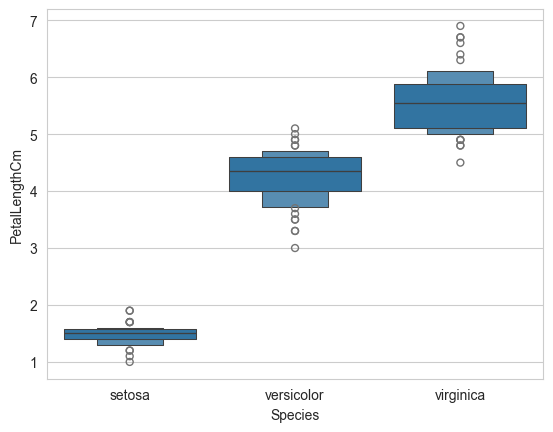

In [111]:
#BOX NAD WHISKERS

sns.boxenplot(x="Species",y ="PetalLengthCm", data=irish)
plt.show()

the box plot shows 25 50 and 75 percentiles 

if i say i use 5 as my threshold
ex:
if pl<5 & pl>2
versicolor
if p>= 5 verginica

whiskers are what the cat has 
what this whiskers mean take maximum and minimum  one way of drawing whiskers is using min max value
seaboarn says i will take 1.5 * IQR
25*1.5 down whisker
75*1.5 up whisker

seaborn uses different mechanism for whiskers



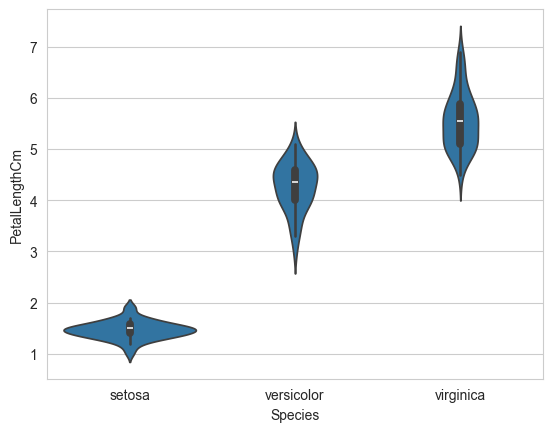

In [ ]:
#Violin Plots

sns.violinplot(x="Species", y="PetalLengthCm", data=irish)
plt.show()

#violin plot plots pdf if you see a distribution is almost it takes histogram and m

#

MultiVariate Probability density, contour plot

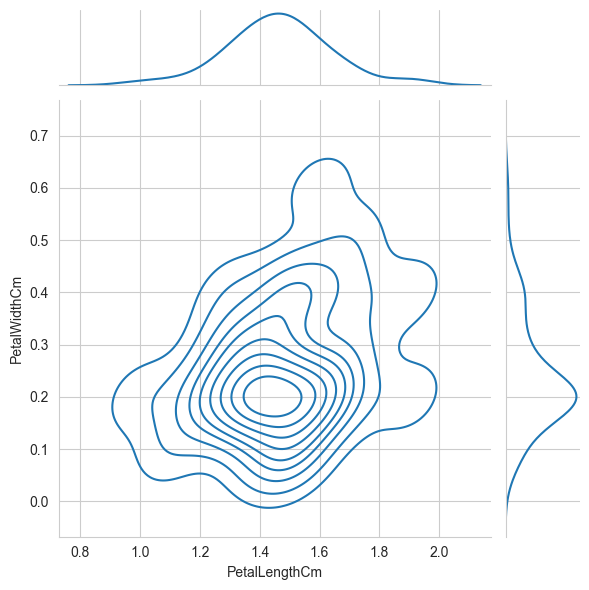

In [115]:
sns.jointplot(x="PetalLengthCm", y = "PetalWidthCm",data = iris_setosa,kind="kde")
plt.show()